# Pipeline startup after pigging: drying a residual MEG/water film

**10 km pipeline · 5 °C · 70 bara · initially 99/1 wt% MEG/water**

This worked example follows the stationary wall film left by the last pig while gas with a
**−18 °C water dew point at 70 bara** flows through the pipeline. NeqSim's SRK–CPA equation of
state supplies gas properties and gas–MEG–water equilibrium; a transparent Python finite-volume
model advances the gas and wall-film component inventories in time.

You will see the initial water-transfer direction, water and MEG inventories, outlet gas quality,
the axial drying front, practical dry-out time, gas consumption, and numerical/physical sensitivity.
**Meeting a water dew-point specification does not demonstrate that the MEG film is gone.**

The illustrative inputs below are editable. The default assumes methane, 300 mm internal diameter,
100 µm uniform full-circumference film, and 1 million Sm³/day. These are assumptions, not supplied
pipeline data. Standard volume means ideal gas at 15 °C and 1.01325 bara.

**Time origin:** the last pig has left the 10 km section; the prescribed film remains everywhere,
and the gas inventory initially has inlet composition. Drying during pig travel, pig motion,
pressurization, and liquid displacement are outside this initial-condition model.

**Completion:** every cell has less than 0.01% of its initial solvent mass left. The model retains
and reports that residue; mathematical zero is not claimed. Change the threshold to explore the tail.

## 1. Clean Colab setup and source provenance

Run all cells from a fresh runtime. The first run builds the current public NeqSim `master` JAR
and may take several minutes. The Python package supplies the JPype bridge; its bundled JAR is
not used. Local validation can supply `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for an already
built, clean checkout. Both paths are verified and provenance remains visible.

The saved run used master commit `ea7d61ac1cbfc4b25689a4e81406a7bef248ae64`.
Set `NEQSIM_SOURCE_REF` to that commit for an exact source replay, or leave `master` to test updates.

In [1]:
import hashlib
import importlib.metadata
import importlib.util
import json
import os
from pathlib import Path
import platform
import subprocess
import sys
from urllib.parse import unquote, urlparse

required_packages = {
    "neqsim": "neqsim==3.23.0",
    "numpy": "numpy",
    "scipy": "scipy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [
    package for module, package in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages],
        check=True,
    )

NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
local_source = os.environ.get("NEQSIM_SOURCE_ROOT")
source_root = Path(local_source or "/content/neqsim-pigging-source").resolve()

def checked_command(arguments, cwd=None):
    result = subprocess.run(
        arguments, cwd=cwd, text=True, capture_output=True, check=False,
    )
    if result.returncode:
        raise RuntimeError(result.stdout[-3000:] + result.stderr[-3000:])
    return result.stdout.strip()

if not local_source:
    if not (source_root / ".git").exists():
        checked_command([
            "git", "clone", "--depth", "1",
            "https://github.com/equinor/neqsim.git", str(source_root),
        ])
    checked_command(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF], source_root)
    checked_command(["git", "checkout", "--detach", "FETCH_HEAD"], source_root)
    checked_command([
        "bash", "mvnw", "-q", "-DskipTests", "-Dmaven.javadoc.skip=true",
        "-Dspotless.skip=true", "-Dcheckstyle.skip=true", "-Dpmd.skip=true",
        "-Dspotbugs.skip=true", "package",
    ], source_root)

source_commit = checked_command(["git", "rev-parse", "HEAD"], source_root)
assert not checked_command(["git", "diff", "--name-only", "HEAD"], source_root)
jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
jar_candidates = [
    path for path in (source_root / "target").glob("neqsim-*.jar")
    if not path.name.endswith(("-sources.jar", "-javadoc.jar"))
]
source_jar = Path(jar_override).resolve() if jar_override else max(
    jar_candidates, key=lambda path: path.stat().st_size,
).resolve()
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype

assert not jpype.isJVMStarted(), "Restart the runtime before changing NeqSim JARs."
jpype.addClassPath(str(source_jar))
jpype.startJVM()
SystemCPA = jpype.JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
ThermodynamicOperations = jpype.JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")
EvaporationStudy = jpype.JClass(
    "neqsim.process.equipment.pipeline.evaporation.PipelineEvaporationStudy"
)
for java_class in [SystemCPA, EvaporationStudy]:
    location = str(java_class.class_.getProtectionDomain().getCodeSource().getLocation())
    loaded_from = Path(unquote(urlparse(location).path)).resolve()
    assert loaded_from == source_jar, (loaded_from, source_jar)

provenance = {
    "source_repository": "https://github.com/equinor/neqsim",
    "requested_ref": NEQSIM_SOURCE_REF,
    "source_commit": source_commit,
    "jar_sha256": jar_sha256,
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python": platform.python_version(),
    "packages": {
        name: importlib.metadata.version(name)
        for name in ["neqsim", "numpy", "scipy", "pandas", "matplotlib"]
    },
}
print(json.dumps(provenance, indent=2))

{
  "source_repository": "https://github.com/equinor/neqsim",
  "requested_ref": "master",
  "source_commit": "ea7d61ac1cbfc4b25689a4e81406a7bef248ae64",
  "jar_sha256": "d110e7f8b0b620d488c6e2aa0881b69ad5dbf6f350016975dbd92b4d2482904f",
  "java": "17.0.20",
  "python": "3.12.14",
  "packages": {
    "neqsim": "3.23.0",
    "numpy": "2.5.3",
    "scipy": "1.18.1",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2"
  }
}


In [2]:
from dataclasses import dataclass, replace
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import solve_ivp
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from scipy.sparse import lil_matrix

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 11})
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", lambda value: f"{value:,.5g}")

@dataclass(frozen=True)
class Case:
    length_m: float = 10_000.0
    diameter_m: float = 0.300
    temperature_C: float = 5.0
    pressure_bara: float = 70.0
    film_thickness_um: float = 100.0
    initial_meg_mass_fraction: float = 0.99
    gas_flow_Sm3_day: float = 1_000_000.0
    water_dew_point_C: float = -18.0
    dew_point_pressure_bara: float = 70.0
    gas_composition: tuple = (("methane", 1.0),)
    # Estimated dilute gas diffusivities at 278.15 K and 1 bara, m2/s.
    water_diffusivity_ref: float = 2.0e-5
    meg_diffusivity_ref: float = 1.0e-5
    mass_transfer_multiplier: float = 1.0
    cells: int = 40
    relative_tolerance: float = 2.0e-6
    completion_fraction: float = 1.0e-4
    patch_fraction: float = 1.0e-6
    maximum_days: float = 3650.0

case = Case()
MW = np.array([0.01801528, 0.0620678])  # water and MEG, kg/mol
R = 8.314462618  # J/(mol K)
SECONDS_PER_DAY = 86400.0
STANDARD_TEMPERATURE_K = 288.15
STANDARD_PRESSURE_PA = 101325.0

assert 0 < case.initial_meg_mass_fraction < 1
assert 0 < case.film_thickness_um * 1e-6 < case.diameter_m / 20
assert case.gas_flow_Sm3_day > 0 and case.pressure_bara > 0
assert all(value > 0 for _, value in case.gas_composition)
assert not {"water", "MEG"}.intersection(name for name, _ in case.gas_composition)
assert 0 < case.patch_fraction < case.completion_fraction < 0.01

display(pd.DataFrame([
    ("Pipeline length", case.length_m / 1000, "km"),
    ("Internal diameter (assumed)", case.diameter_m * 1000, "mm"),
    ("Uniform film thickness (assumed)", case.film_thickness_um, "µm"),
    ("Initial MEG fraction (solvent basis)", 100 * case.initial_meg_mass_fraction, "wt%"),
    ("Pipeline temperature", case.temperature_C, "°C"),
    ("Pipeline pressure (assumed constant)", case.pressure_bara, "bara"),
    ("Gas flow (assumed)", case.gas_flow_Sm3_day, "Sm³/day"),
    ("Water dew point", case.water_dew_point_C, f"°C at {case.dew_point_pressure_bara:g} bara"),
    ("Residual fraction in every cell", case.completion_fraction, "kg/kg initial"),
], columns=["Input", "Value", "Unit / basis"]))
print("Dry carrier composition:", dict(case.gas_composition))

Dry carrier composition: {'methane': 1.0}


,Input,Value,Unit / basis
0,Pipeline length,10,km
1,Internal diameter (assumed),300,mm
2,Uniform film thickness (assumed),100,µm
3,Initial MEG fraction (solvent basis),99,wt%
4,Pipeline temperature,5,°C
5,Pipeline pressure (assumed constant),70,bara
6,Gas flow (assumed),1e+06,Sm³/day
7,Water dew point,-18,°C at 70 bara
8,Residual fraction in every cell,0.0001,kg/kg initial


## 2. Equilibrium first: will water evaporate or be absorbed?

SRK–CPA (`SystemSrkCPAstatoil`, mixing rule 10) is used for associating MEG/water mixtures.
Each lookup state is a two-phase gas–aqueous flash. The **actual liquid solvent composition after
the flash** is the interpolation coordinate, avoiding confusion between feed and liquid composition.
Dissolved carrier gas is equilibrated in these flashes; its small changing film inventory is omitted
from the subsequent trace-species balance.

The inlet specification is interpreted as a **metastable liquid-water dew point**, with ice and
hydrates excluded. A frost-point specification would imply a different water content; confirm the
instrument convention before applying this case to a real pipeline. The outlet quantity plotted later
is an equivalent **water-only dew point**, not the first condensation temperature of a MEG-containing gas.

Water and MEG are tracked as molar ratios to dry carrier gas:

$$r_i=\frac{n_i^{g}}{n_{\mathrm{dry}}^{g}},\qquad w_w=\frac{n_w^\ell M_w}{n_w^\ell M_w+n_m^\ell M_m}.$$

Here $i$ is water ($w$) or MEG ($m$), $n$ is amount in mol, $M$ is molar mass in kg/mol,
and $w_w$ is the liquid water mass fraction on a water-plus-MEG basis. Lookup values $r_i^*(w_w)$
come from NeqSim at the pipeline temperature and pressure.

In [3]:
def equilibrium_point(water_fraction, temperature_C, pressure_bara, composition):
    fluid = SystemCPA(temperature_C + 273.15, pressure_bara)
    composition_sum = sum(value for _, value in composition)
    for name, value in composition:
        fluid.addComponent(name, 1000.0 * value / composition_sum)
    # A large liquid reservoir minimizes loss of the requested film composition.
    fluid.addComponent("water", max(1e-12, 100.0 * water_fraction / MW[0]))
    fluid.addComponent("MEG", max(1e-12, 100.0 * (1 - water_fraction) / MW[1]))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    assert fluid.getNumberOfPhases() == 2, "This model requires only gas and aqueous liquid."
    gas = fluid.getPhase("gas")
    liquid = fluid.getPhase("aqueous")
    dry_mole_fraction = sum(gas.getComponent(name).getx() for name, _ in composition)
    ratios = np.array([
        gas.getComponent(name).getx() / dry_mole_fraction
        for name in ["water", "MEG"]
    ])
    solvent_mass = np.array([
        liquid.getComponent(name).getNumberOfMolesInPhase() * molar_mass
        for name, molar_mass in zip(["water", "MEG"], MW)
    ])
    actual_water_fraction = solvent_mass[0] / solvent_mass.sum()
    residuals = []
    for name in ["water", "MEG"]:
        gas_component = gas.getComponent(name)
        liquid_component = liquid.getComponent(name)
        gas_fugacity = gas_component.getx() * gas_component.getFugacityCoefficient()
        liquid_fugacity = liquid_component.getx() * liquid_component.getFugacityCoefficient()
        residuals.append(abs(np.log(gas_fugacity / liquid_fugacity)))
    return {
        "water_fraction": actual_water_fraction,
        "ratios": ratios,
        "density_kg_m3": liquid.getDensity("kg/m3"),
        "max_log_fugacity_residual": max(residuals),
    }

water_grid = np.unique(np.r_[
    0.0, np.geomspace(1e-7, 0.01, 14), np.linspace(0.01, 1.0, 61),
])
equilibrium_rows = [
    equilibrium_point(float(value), case.temperature_C, case.pressure_bara, case.gas_composition)
    for value in water_grid
]
liquid_water_grid = np.array([row["water_fraction"] for row in equilibrium_rows])
ratio_grid = np.array([row["ratios"] for row in equilibrium_rows])
density_grid = np.array([row["density_kg_m3"] for row in equilibrium_rows])
ratio_lookup = PchipInterpolator(liquid_water_grid, ratio_grid, axis=0, extrapolate=False)
density_lookup = PchipInterpolator(liquid_water_grid, density_grid, extrapolate=False)

def film_equilibrium(water_fraction):
    bounded_fraction = np.clip(water_fraction, liquid_water_grid[0], liquid_water_grid[-1])
    return ratio_lookup(bounded_fraction)

inlet_point = equilibrium_point(
    1.0, case.water_dew_point_C, case.dew_point_pressure_bara, case.gas_composition,
)
inlet_ratios = np.array([inlet_point["ratios"][0], 0.0])
initial_water_fraction = 1 - case.initial_meg_mass_fraction
initial_ratios = film_equilibrium(initial_water_fraction)
water_balance_fraction = brentq(
    lambda value: film_equilibrium(value)[0] - inlet_ratios[0], 0.0, 1.0,
)
max_fugacity_residual = max(row["max_log_fugacity_residual"] for row in equilibrium_rows)
assert max_fugacity_residual < 1e-5

def ratios_to_ppmv(ratios):
    values = np.asarray(ratios)
    return 1e6 * values / (1 + values.sum(axis=-1, keepdims=True))

vle_summary = pd.DataFrame([
    ["Inlet gas", *ratios_to_ppmv(inlet_ratios)],
    ["Gas in equilibrium with initial film", *ratios_to_ppmv(initial_ratios)],
    [f"Gas over pure water at {case.temperature_C:g} °C", *ratios_to_ppmv(ratio_grid[-1])],
], columns=["State", "Water [ppmv]", "MEG [ppmv]"])
display(vle_summary)
print(
    f"Zero water-flux liquid composition at inlet gas: "
    f"{100 * water_balance_fraction:.3f} wt% water"
)
print(f"Maximum CPA log-fugacity residual: {max_fugacity_residual:.3e}")
print("Initial water direction:", "ABSORPTION into film" if inlet_ratios[0] > initial_ratios[0]
      else "EVAPORATION from film")
print("The zero-water-flux composition is not a final state: MEG continues to evaporate.")

Zero water-flux liquid composition at inlet gas: 7.389 wt% water
Maximum CPA log-fugacity residual: 5.338e-11
Initial water direction: ABSORPTION into film
The zero-water-flux composition is not a final state: MEG continues to evaporate.


,State,Water [ppmv],MEG [ppmv]
0,Inlet gas,35.536,0
1,Gas in equilibrium with initial film,5.7025,0.7593
2,Gas over pure water at 5 °C,176.88,6.8744e-17


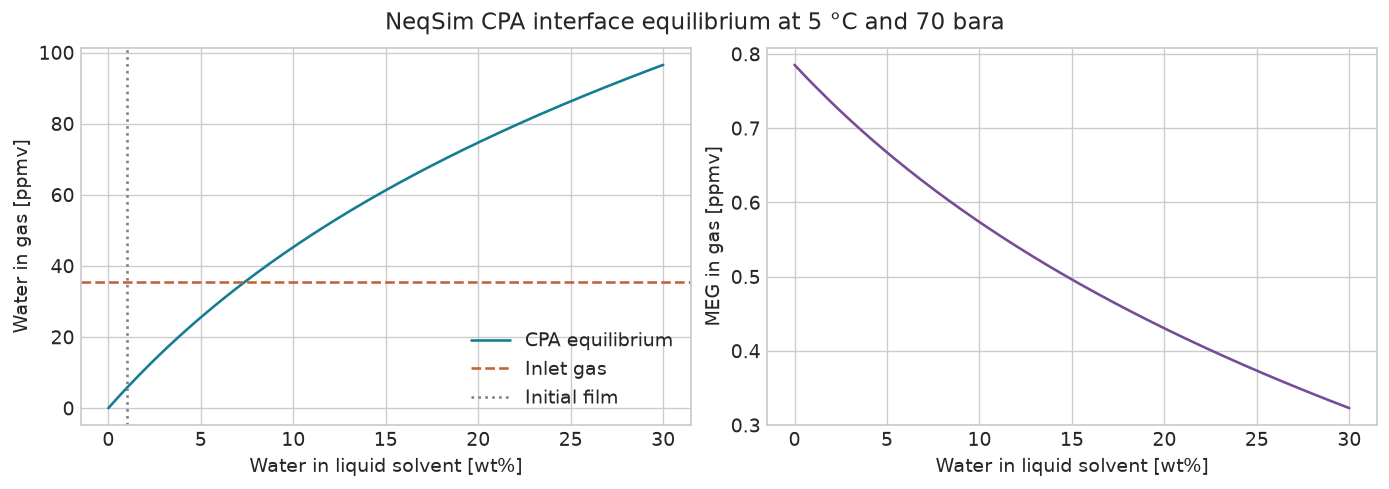

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
plot_water = np.linspace(0, 0.30, 250)
plot_ppmv = ratios_to_ppmv(film_equilibrium(plot_water))
axes[0].plot(plot_water * 100, plot_ppmv[:, 0], color="#147d92", label="CPA equilibrium")
axes[0].axhline(ratios_to_ppmv(inlet_ratios)[0], color="#bf6538", ls="--", label="Inlet gas")
axes[0].axvline(initial_water_fraction * 100, color="gray", ls=":", label="Initial film")
axes[0].set(xlabel="Water in liquid solvent [wt%]", ylabel="Water in gas [ppmv]")
axes[0].legend()
axes[1].plot(plot_water * 100, plot_ppmv[:, 1], color="#754c97")
axes[1].set(xlabel="Water in liquid solvent [wt%]", ylabel="MEG in gas [ppmv]")
fig.suptitle(
    f"NeqSim CPA interface equilibrium at {case.temperature_C:g} °C "
    f"and {case.pressure_bara:g} bara"
)
plt.show()

## 3. Finite-rate model, gas transport and assumptions

The pipe is divided into equal, well-mixed gas cells with **stationary, internally mixed films**.
Gas advects between cells; no film drains or is entrained. Temperature and pressure are imposed.
Gas is dilute in water/MEG (checked below), so the dry-carrier molar density $c_d$ and flow $F_d$
are held constant. Gas holdup is retained: startup is not treated as an instantaneous axial flash.

$$\dot N_{i,j}=k_i c_d A_j a_j\left(r_i^*(w_{w,j})-r_{i,j}\right).$$

$$\frac{dn_{i,j}^\ell}{dt}=-\dot N_{i,j},\qquad H_j\frac{dr_{i,j}}{dt}=F_d(r_{i,j-1}-r_{i,j})+\dot N_{i,j}.$$

$\dot N$ is film-to-gas transfer in mol/s (negative permits absorption); $k_i$ is a gas-side
coefficient in m/s; $A_j=\pi D\Delta z$ is wall area in m²; $a_j$ is the wetted-area factor;
$H_j=c_d\pi D^2\Delta z/4$ is dry gas holdup in mol; $F_d$ is dry molar flow in mol/s.
The inlet boundary has constant $r_{i,0}$. No liquid-phase resistance is resolved.

The Chilton–Colburn mass-transfer/friction analogy is used as a screening closure:

$$k_i=\frac{f_Du}{8\,\mathrm{Sc}_i^{2/3}},\qquad f_D=(0.79\ln\mathrm{Re}-1.64)^{-2}.$$

$f_D$ is the Darcy friction factor (four times the Fanning factor), estimated with the smooth-pipe
Petukhov expression. $\mathrm{Re}=\rho_g uD/\mu_g$, $\mathrm{Sc}_i=\mu_g/(\rho_gD_{i,g})$, and $D_{i,g}$ is an
estimated diffusivity in m²/s, scaled approximately as temperature to power 1.75 and inverse pressure.
The reference values and correlation are **screening assumptions**, not high-pressure transport
measurements. A 0.5×/2× coefficient sensitivity is provided. Low-Reynolds-number cases are rejected.

$$a_j=\frac{m_j}{m_j+\epsilon m_{j,0}}.$$

This small-residue area taper avoids discontinuous disappearance of the liquid phase. Its default
$\epsilon=10^{-6}$ is much smaller than the $10^{-4}$ completion threshold; a taper sensitivity is
included. It is a numerical end-stage model, not a measured wetting law.

The stiff balance equations use SciPy BDF. All reported balances include gas accumulation and the
integrated **net** water/MEG export. Tiny negative solver excursions are checked against an explicit
mass tolerance; they are not erased from the balance ledger.

In [5]:
carrier = SystemCPA(case.temperature_C + 273.15, case.pressure_bara)
for component, amount in case.gas_composition:
    carrier.addComponent(component, amount)
carrier.setMixingRule(10)
ThermodynamicOperations(carrier).TPflash()
carrier.initProperties()
assert carrier.getNumberOfPhases() == 1
assert carrier.getPhase(0).getType() == jpype.JClass("neqsim.thermo.phase.PhaseType").GAS
gas_density = carrier.getDensity("kg/m3")
gas_viscosity = carrier.getViscosity("kg/msec")
gas_z = carrier.getZ()
carrier_molar_mass = carrier.getMolarMass()
carrier_molar_density = case.pressure_bara * 1e5 / (
    gas_z * R * (case.temperature_C + 273.15)
)

# Named NeqSim stream and process remain available for composition/flowsheet integration.
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")
inlet_fluid = carrier.clone()
inlet_fluid.addComponent("water", inlet_ratios[0] * sum(v for _, v in case.gas_composition))
inlet_fluid.setMixingRule(10)
inlet_fluid.setTotalFlowRate(case.gas_flow_Sm3_day, "Sm3/day")
inlet_stream = Stream("Post-pigging inlet gas", inlet_fluid)
process = ProcessSystem()
process.add(inlet_stream)
process.run()

def flow_properties(settings):
    cross_section = np.pi * settings.diameter_m**2 / 4
    dry_flow = settings.gas_flow_Sm3_day / SECONDS_PER_DAY * (
        STANDARD_PRESSURE_PA / (R * STANDARD_TEMPERATURE_K)
    )
    velocity = dry_flow / (carrier_molar_density * cross_section)
    reynolds = gas_density * velocity * settings.diameter_m / gas_viscosity
    assert reynolds > 10_000, "The example transfer correlation requires turbulent gas flow."
    diffusivity = np.array([
        settings.water_diffusivity_ref, settings.meg_diffusivity_ref,
    ]) * ((settings.temperature_C + 273.15) / 278.15)**1.75 / settings.pressure_bara
    schmidt = gas_viscosity / (gas_density * diffusivity)
    friction_factor = (0.79 * np.log(reynolds) - 1.64)**-2
    coefficients = (
        settings.mass_transfer_multiplier * friction_factor * velocity / (8 * schmidt**(2 / 3))
    )
    # The same smooth-pipe Darcy factor screens the constant-pressure assumption.
    pressure_drop_bar = (
        friction_factor * settings.length_m / settings.diameter_m
        * gas_density * velocity**2 / 2 / 1e5
    )
    return dry_flow, velocity, reynolds, coefficients, pressure_drop_bar

flow, velocity, reynolds, coefficients, pressure_drop_bar = flow_properties(case)
film_density = float(density_lookup(initial_water_fraction))
thickness_m = case.film_thickness_um * 1e-6
initial_film_volume = np.pi * (
    case.diameter_m * thickness_m - thickness_m**2
) * case.length_m
initial_film_mass = initial_film_volume * film_density
residence_hours = case.length_m / velocity / 3600

display(pd.DataFrame([
    ("Initial film volume", initial_film_volume, "m³"),
    ("Initial film mass", initial_film_mass, "kg"),
    ("Initial water mass", initial_film_mass * initial_water_fraction, "kg"),
    ("Initial MEG mass", initial_film_mass * case.initial_meg_mass_fraction, "kg"),
    ("CPA gas density", gas_density, "kg/m³"),
    ("Gas velocity", velocity, "m/s"),
    ("Gas residence time", residence_hours, "h"),
    ("Reynolds number", reynolds, "–"),
    ("Water mass-transfer coefficient", coefficients[0], "m/s"),
    ("MEG mass-transfer coefficient", coefficients[1], "m/s"),
    ("Smooth-pipe pressure-drop screen", pressure_drop_bar, "bar"),
], columns=["Quantity", "Value", "Unit"]))
assert pressure_drop_bar / case.pressure_bara < 0.05, "Use a pressure profile for this case."
print("Temperature is imposed: heat required for evaporation comes from the pipe surroundings.")

Temperature is imposed: heat required for evaporation comes from the pipe surroundings.


,Quantity,Value,Unit
0,Initial film volume,0.94216,m³
1,Initial film mass,"1,050.7",kg
2,Initial water mass,10.507,kg
3,Initial MEG mass,"1,040.2",kg
4,CPA gas density,56.522,kg/m³
5,Gas velocity,1.9655,m/s
6,Gas residence time,1.4132,h
7,Reynolds number,2.69e+06,–
8,Water mass-transfer coefficient,0.0028991,m/s
9,MEG mass-transfer coefficient,0.0018263,m/s


In [6]:
def simulate(settings):
    count = settings.cells
    dry_flow, gas_velocity, _, transfer_coefficients, _ = flow_properties(settings)
    cell_length = settings.length_m / count
    wall_area = np.pi * settings.diameter_m * cell_length
    gas_holdup = carrier_molar_density * np.pi * settings.diameter_m**2 / 4 * cell_length
    film_thickness = settings.film_thickness_um * 1e-6
    cell_mass = film_density * np.pi * (
        settings.diameter_m * film_thickness - film_thickness**2
    ) * cell_length
    initial_moles = cell_mass * np.array([
        initial_water_fraction, 1 - initial_water_fraction,
    ]) / MW
    initial_state = np.r_[
        np.tile(initial_moles, (count, 1)).ravel(),
        np.tile(inlet_ratios, (count, 1)).ravel(),
        [0.0, 0.0],
    ]

    def rate_equations(seconds, state):
        film_moles = state[:2 * count].reshape(count, 2)
        gas_ratios = state[2 * count:4 * count].reshape(count, 2)
        # Only constitutive evaluation uses bounded trial states; inventory is unmodified.
        film_mass = np.maximum(film_moles, 0.0) * MW
        total_mass = film_mass.sum(axis=1)
        water_fraction = np.divide(
            film_mass[:, 0], total_mass, out=np.ones(count), where=total_mass > 0,
        )
        wetted_fraction = total_mass / (total_mass + settings.patch_fraction * cell_mass)
        transfer = (
            transfer_coefficients * carrier_molar_density * wall_area
            * wetted_fraction[:, None]
            * (film_equilibrium(water_fraction) - gas_ratios)
        )
        upstream_ratios = np.vstack([inlet_ratios, gas_ratios[:-1]])
        gas_derivative = (dry_flow * (upstream_ratios - gas_ratios) + transfer) / gas_holdup
        net_export = dry_flow * (gas_ratios[-1] - inlet_ratios)
        return np.r_[-transfer.ravel(), gas_derivative.ravel(), net_export]

    def all_cells_dry(seconds, state):
        masses = state[:2 * count].reshape(count, 2) @ MW
        return masses.max() / cell_mass - settings.completion_fraction

    all_cells_dry.terminal = True
    all_cells_dry.direction = -1
    sparsity = lil_matrix((4 * count + 2, 4 * count + 2))
    for cell_number in range(count):
        indices = [
            2 * cell_number, 2 * cell_number + 1,
            2 * count + 2 * cell_number, 2 * count + 2 * cell_number + 1,
        ]
        for row_index in indices:
            sparsity[row_index, indices] = 1
        if cell_number:
            row_start = 2 * count + 2 * cell_number
            sparsity[row_start:row_start + 2, row_start - 2:row_start] = 1
    sparsity[-2:, 4 * count - 2:4 * count] = 1
    absolute_tolerances = np.r_[
        np.full(2 * count, 1e-9), np.full(2 * count, 1e-13), [1e-7, 1e-7],
    ]
    started = time.monotonic()
    solution = solve_ivp(
        rate_equations,
        (0.0, settings.maximum_days * SECONDS_PER_DAY),
        initial_state,
        method="BDF",
        rtol=settings.relative_tolerance,
        atol=absolute_tolerances,
        jac_sparsity=sparsity.tocsr(),
        events=all_cells_dry,
        dense_output=True,
    )
    assert solution.success, solution.message
    return {
        "settings": settings,
        "solution": solution,
        "cell_initial_mass": cell_mass,
        "gas_holdup_mol": gas_holdup,
        "dry_flow_mol_s": dry_flow,
        "runtime_s": time.monotonic() - started,
        "complete": bool(len(solution.t_events[0])),
        "last_day": solution.t[-1] / SECONDS_PER_DAY,
    }

baseline = simulate(case)
print(f"Simulation complete: {baseline['complete']}")
print(f"Last simulated day: {baseline['last_day']:.3f}")
print(
    f"Runtime: {baseline['runtime_s']:.1f} s; "
    f"accepted time points: {len(baseline['solution'].t)}"
)
if not baseline["complete"]:
    print("The residual criterion was NOT reached; increase maximum_days or change conditions.")

Simulation complete: True
Last simulated day: 644.263
Runtime: 7.4 s; accepted time points: 9149


## 4. Startup history and practical film removal

The initial film can become wetter while MEG is evaporating. After the water content adjusts,
MEG removal controls the long drying front. The following results are model predictions under
the assumed geometry, transport coefficients and isothermal boundary, not a field-qualified duration.

,Result,Value,Unit
0,Practical all-cell film removal,644.26,day
1,Gas used to criterion,644.26,million Sm³
2,Initial water,10.507,kg
3,Maximum water in film,82.597,kg
4,Day of maximum water inventory,5.9567,day
5,Water left at criterion,0.00019475,kg
6,MEG left at criterion,0.0024316,kg
7,Total residue retained,0.0026264,kg


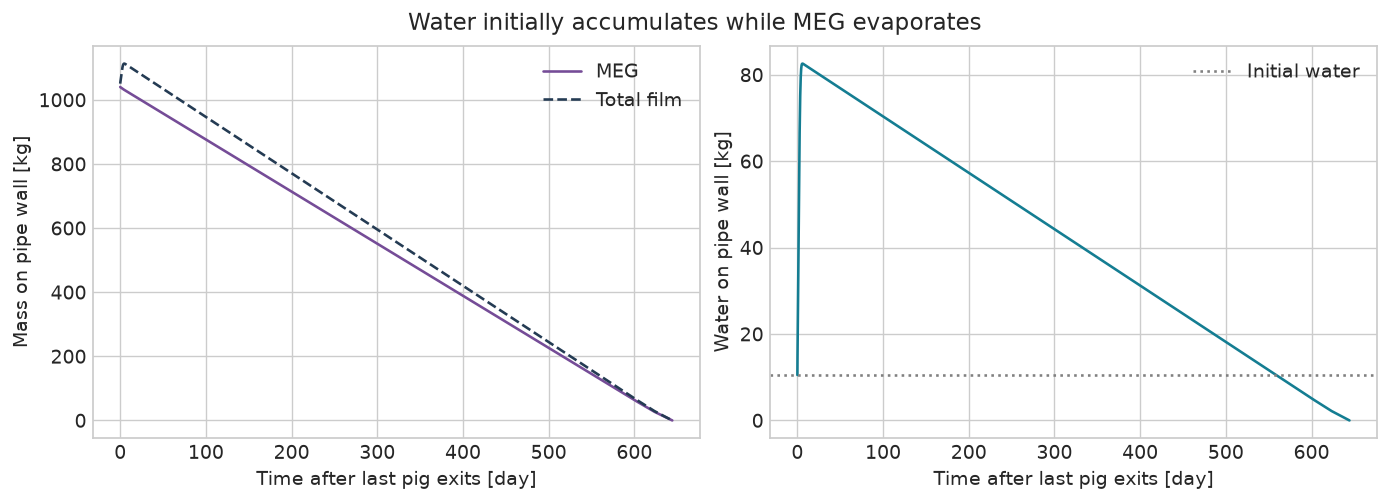

In [7]:
def extract_history(result, days):
    count = result["settings"].cells
    state = result["solution"].sol(np.asarray(days) * SECONDS_PER_DAY)
    film = state[:2 * count].reshape(count, 2, -1)
    gas = state[2 * count:4 * count].reshape(count, 2, -1)
    film_mass = film * MW[None, :, None]
    total = film_mass.sum(axis=1)
    water_fraction = np.divide(
        film_mass[:, 0], total, out=np.full_like(total, np.nan), where=total > 1e-7,
    )
    outlet_ratios = gas[-1].T
    return state, film_mass, gas, water_fraction, outlet_ratios

sample_days = np.unique(np.r_[
    0.0, np.geomspace(1e-5, baseline["last_day"], 550), baseline["last_day"],
])
state, film_history, gas_history, water_history, outlet_ratios = extract_history(
    baseline, sample_days,
)
inventory_history = film_history.sum(axis=0).T
outlet_ppmv = ratios_to_ppmv(outlet_ratios)
peak_water_index = np.argmax(inventory_history[:, 0])
residual_kg = inventory_history[-1].sum()
summary = pd.DataFrame([
    ("Practical all-cell film removal", baseline["last_day"], "day"),
    ("Gas used to criterion", baseline["last_day"] * case.gas_flow_Sm3_day / 1e6, "million Sm³"),
    ("Initial water", inventory_history[0, 0], "kg"),
    ("Maximum water in film", inventory_history[peak_water_index, 0], "kg"),
    ("Day of maximum water inventory", sample_days[peak_water_index], "day"),
    ("Water left at criterion", inventory_history[-1, 0], "kg"),
    ("MEG left at criterion", inventory_history[-1, 1], "kg"),
    ("Total residue retained", residual_kg, "kg"),
], columns=["Result", "Value", "Unit"])
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained")
axes[0].plot(sample_days, inventory_history[:, 1], color="#754c97", label="MEG")
axes[0].plot(
    sample_days, inventory_history.sum(axis=1), color="#243b53", ls="--", label="Total film",
)
axes[0].set(xlabel="Time after last pig exits [day]", ylabel="Mass on pipe wall [kg]")
axes[0].legend()
axes[1].plot(sample_days, inventory_history[:, 0], color="#147d92")
axes[1].axhline(inventory_history[0, 0], color="gray", ls=":", label="Initial water")
axes[1].set(xlabel="Time after last pig exits [day]", ylabel="Water on pipe wall [kg]")
axes[1].legend()
fig.suptitle("Water initially accumulates while MEG evaporates")
plt.show()

Hydrate and ice formation are not simulated; dew point is a composition indicator only.


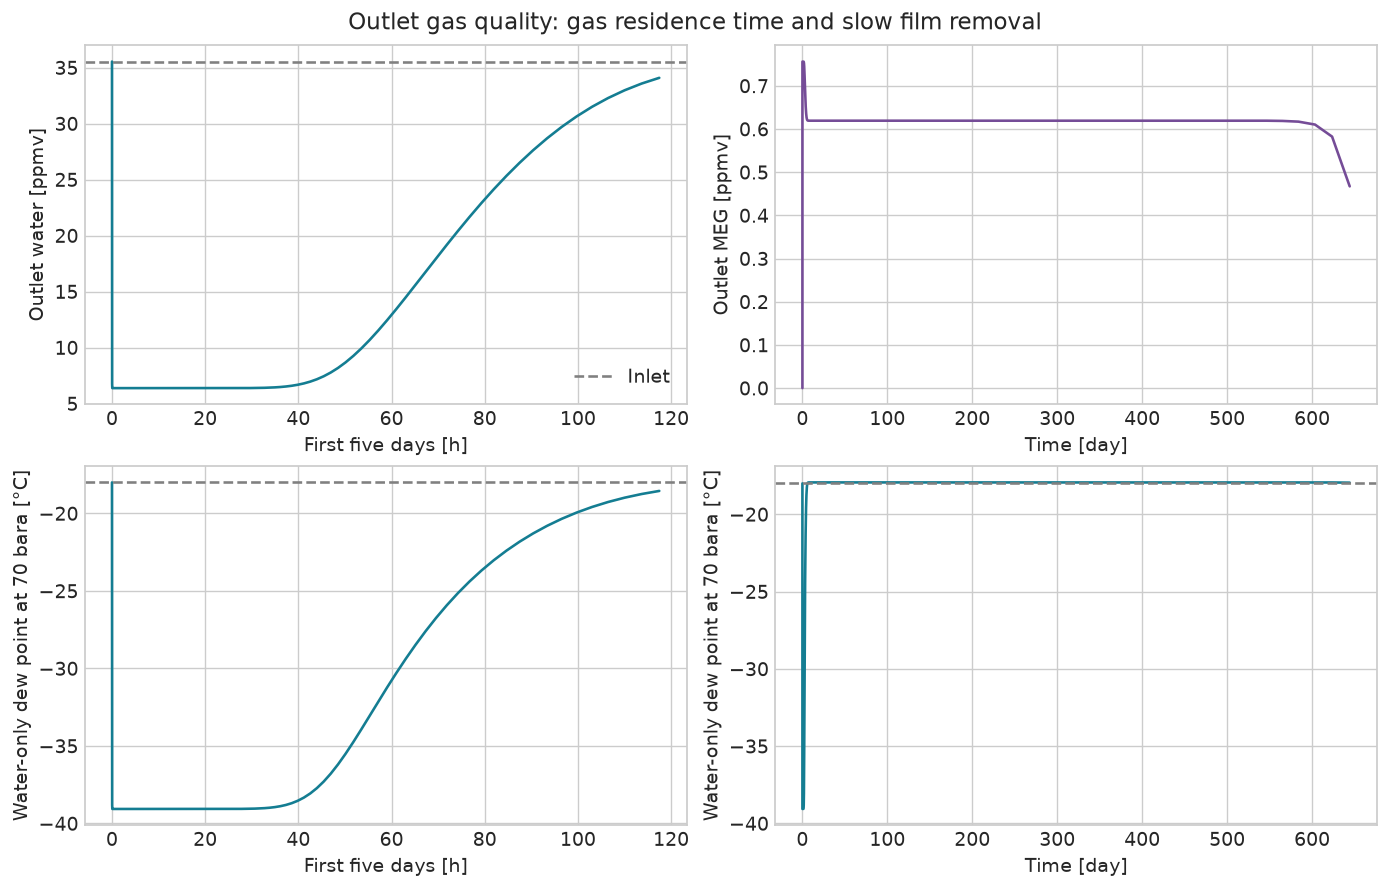

In [8]:
# Map water content to the same metastable liquid-water dew-point convention.
dew_temperatures = np.linspace(-65.0, max(10.0, case.temperature_C + 5), 80)
dew_ratios = np.array([
    equilibrium_point(
        1.0, float(temp), case.dew_point_pressure_bara, case.gas_composition,
    )["ratios"][0]
    for temp in dew_temperatures
])
assert np.all(np.diff(dew_ratios) > 0)
dew_lookup = PchipInterpolator(np.log(dew_ratios), dew_temperatures, extrapolate=False)
outlet_dew_C = dew_lookup(np.log(np.maximum(outlet_ratios[:, 0], 1e-30)))
assert np.all(np.isfinite(outlet_dew_C)), "Extend the dew-point lookup range."

fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout="constrained")
early = sample_days <= 5
axes[0, 0].plot(sample_days[early] * 24, outlet_ppmv[early, 0], color="#147d92")
axes[0, 0].axhline(ratios_to_ppmv(inlet_ratios)[0], color="gray", ls="--", label="Inlet")
axes[0, 0].set(xlabel="First five days [h]", ylabel="Outlet water [ppmv]")
axes[0, 0].legend()
axes[0, 1].plot(sample_days, outlet_ppmv[:, 1], color="#754c97")
axes[0, 1].set(xlabel="Time [day]", ylabel="Outlet MEG [ppmv]")
axes[1, 0].plot(sample_days[early] * 24, outlet_dew_C[early], color="#147d92")
axes[1, 0].axhline(case.water_dew_point_C, color="gray", ls="--")
dew_label = f"Water-only dew point at {case.dew_point_pressure_bara:g} bara [°C]"
axes[1, 0].set(xlabel="First five days [h]", ylabel=dew_label)
axes[1, 1].plot(sample_days, outlet_dew_C, color="#147d92")
axes[1, 1].axhline(case.water_dew_point_C, color="gray", ls="--")
axes[1, 1].set(xlabel="Time [day]", ylabel=dew_label)
fig.suptitle("Outlet gas quality: gas residence time and slow film removal")
plt.show()
print("Hydrate and ice formation are not simulated; dew point is a composition indicator only.")

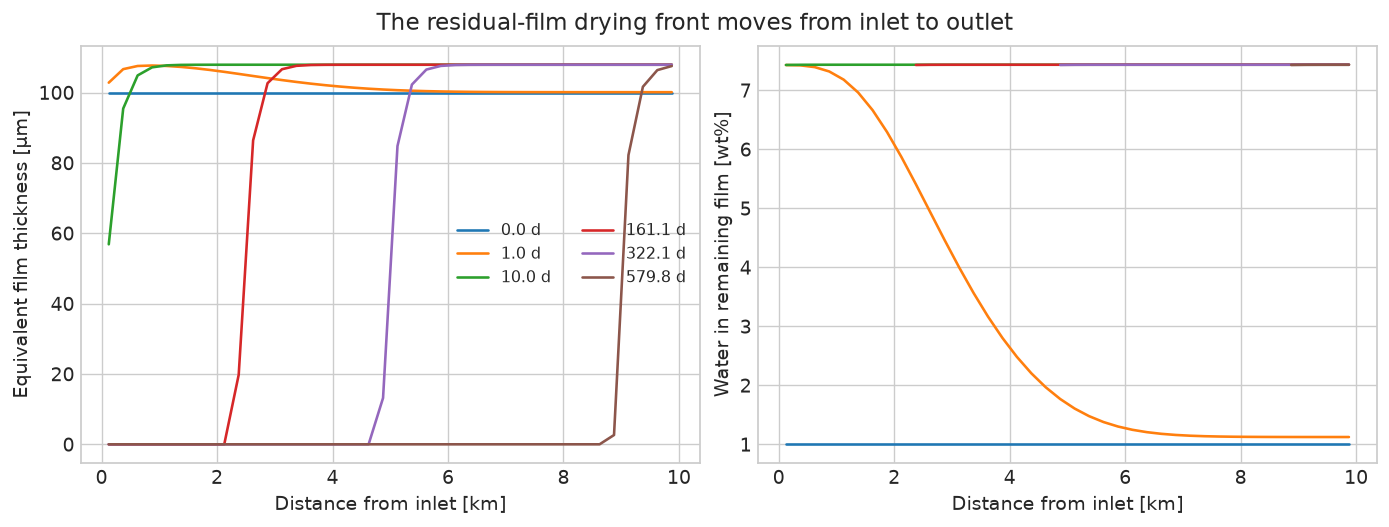

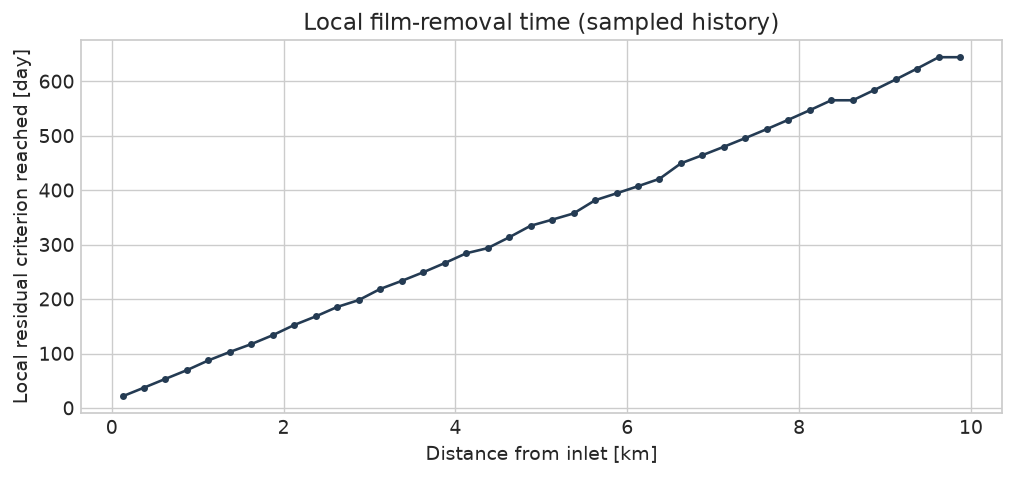

In [9]:
snapshot_days = np.array([0.0, 1.0, 10.0, 0.25, 0.50, 0.90])
snapshot_days[3:] *= baseline["last_day"]
_, snapshot_film, _, snapshot_water, _ = extract_history(baseline, snapshot_days)
locations_km = (np.arange(case.cells) + 0.5) * case.length_m / case.cells / 1000
cell_wall_area = np.pi * case.diameter_m * case.length_m / case.cells
snapshot_total = snapshot_film.sum(axis=1)
valid_water = np.nan_to_num(snapshot_water, nan=initial_water_fraction)
snapshot_density = density_lookup(np.clip(
    valid_water, liquid_water_grid[0], liquid_water_grid[-1],
))
# Thin-film equivalent thickness; volume is divided by original wetted wall area.
snapshot_thickness_um = snapshot_total / (snapshot_density * cell_wall_area) * 1e6

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1), layout="constrained")
for column, day in enumerate(snapshot_days):
    label = f"{day:.1f} d"
    axes[0].plot(locations_km, snapshot_thickness_um[:, column], label=label)
    wet = snapshot_total[:, column] > baseline["cell_initial_mass"] * case.completion_fraction
    axes[1].plot(locations_km, np.where(wet, 100 * snapshot_water[:, column], np.nan))
axes[0].set(xlabel="Distance from inlet [km]", ylabel="Equivalent film thickness [µm]")
axes[1].set(xlabel="Distance from inlet [km]", ylabel="Water in remaining film [wt%]")
axes[0].legend(ncol=2, fontsize=9)
fig.suptitle("The residual-film drying front moves from inlet to outlet")
plt.show()

fractions = film_history.sum(axis=1) / baseline["cell_initial_mass"]
completion_times = []
for cell_number in range(case.cells):
    passed = np.flatnonzero(fractions[cell_number] <= case.completion_fraction * 1.001)
    completion_times.append(sample_days[passed[0]] if len(passed) else np.nan)
fig, axis = plt.subplots(figsize=(8, 3.7), layout="constrained")
axis.plot(locations_km, completion_times, color="#243b53", marker=".")
axis.set(xlabel="Distance from inlet [km]", ylabel="Local residual criterion reached [day]")
axis.set_title("Local film-removal time (sampled history)")
plt.show()

## 5. Conservation and independent limiting checks

The two trace-component balances are checked across all accepted solver steps:

$$B_i(t)=\sum_j n_{i,j}^\ell(t)+\sum_j H_jr_{i,j}(t)+\int_0^t F_d(r_{i,\mathrm{out}}-r_{i,\mathrm{in}})\,dt.$$

$B_i$ must equal its initial value in mol. A negative integrated net water export is legitimate:
water has moved from the incoming gas into the film.

A capacity lower bound uses the **maximum CPA MEG vapor ratio anywhere in the liquid-composition
lookup**. It assumes gas leaves fully saturated at that maximum at all times and neglects resistance.
The gas can still contain MEG at the film-residue criterion because the gas holdup has not yet
been purged. The figures stop at the film criterion, not at a zero-MEG outlet reading.

Removal faster than this bound would violate the model's available vapor capacity. The small MEG
inventory in the gas is included in the bound. This is an analytical check, not an experimental validation.

In [10]:
def balance_check(result):
    count = result["settings"].cells
    solution = result["solution"]
    film = solution.y[:2 * count].reshape(count, 2, -1)
    gas = solution.y[2 * count:4 * count].reshape(count, 2, -1)
    total = film.sum(axis=0) + result["gas_holdup_mol"] * gas.sum(axis=0) + solution.y[-2:]
    mass_residual = (total - total[:, [0]]) * MW[:, None]
    maximum_error = np.max(np.abs(mass_residual), axis=1)
    minimum_component_mass = float(np.min(film * MW[None, :, None]))
    assert np.all(maximum_error < 1e-5), maximum_error
    assert minimum_component_mass > -1e-5, minimum_component_mass
    assert gas.min() > -1e-10
    assert gas.sum(axis=1).max() < 0.005, "Trace-species gas approximation is no longer adequate."
    return maximum_error, minimum_component_mass

balance_error, minimum_mass = balance_check(baseline)
maximum_meg_ratio = ratio_grid[:, 1].max()
initial_meg_kg = inventory_history[0, 1]
maximum_gas_meg_kg = case.cells * baseline["gas_holdup_mol"] * maximum_meg_ratio * MW[1]
capacity_kg_day = flow * maximum_meg_ratio * MW[1] * SECONDS_PER_DAY
capacity_lower_bound_days = max(
    0.0, initial_meg_kg - residual_kg - maximum_gas_meg_kg,
) / capacity_kg_day
assert baseline["last_day"] >= capacity_lower_bound_days
assert inventory_history[peak_water_index, 0] > inventory_history[0, 0]

# A no-transfer gas-tracer step has the analytical N-CSTR-in-series response.
from scipy.special import gammainc
tracer_cells = 12
tracer_tau_s = 50.0
tracer_times = np.linspace(0, 1600, 160)

def tracer_rhs(seconds, concentration):
    return (np.r_[1.0, concentration[:-1]] - concentration) / tracer_tau_s

tracer_solution = solve_ivp(
    tracer_rhs, (0, tracer_times[-1]), np.zeros(tracer_cells),
    t_eval=tracer_times, rtol=1e-9, atol=1e-11,
)
tracer_exact = gammainc(tracer_cells, tracer_times / tracer_tau_s)
tracer_error = np.max(np.abs(tracer_solution.y[-1] - tracer_exact))
assert tracer_error < 1e-7

validation_table = pd.DataFrame([
    ("Water balance maximum residual", balance_error[0], "kg", "< 1e-5"),
    ("MEG balance maximum residual", balance_error[1], "kg", "< 1e-5"),
    ("Minimum component mass in a cell", minimum_mass, "kg", "> -1e-5"),
    ("Maximum CPA log-fugacity residual", max_fugacity_residual, "–", "< 1e-5"),
    ("MEG vapor-capacity lower bound", capacity_lower_bound_days, "day", "≤ simulated time"),
    ("Analytical gas-advection error", tracer_error, "fraction", "< 1e-7"),
], columns=["Check", "Result", "Unit", "Acceptance"])
display(validation_table)
print(f"MEG maximum equilibrium carrying capacity: {capacity_kg_day:.3f} kg/day")
print("No measured pipeline dry-out time is used for validation or calibration.")

MEG maximum equilibrium carrying capacity: 2.062 kg/day
No measured pipeline dry-out time is used for validation or calibration.


,Check,Result,Unit,Acceptance
0,Water balance maximum residual,1.6135e-08,kg,< 1e-5
1,MEG balance maximum residual,4.6879e-09,kg,< 1e-5
2,Minimum component mass in a cell,-1.1896e-07,kg,> -1e-5
3,Maximum CPA log-fugacity residual,5.3384e-11,–,< 1e-5
4,MEG vapor-capacity lower bound,504.51,day,≤ simulated time
5,Analytical gas-advection error,8.3865e-10,fraction,< 1e-7


## 6. Numerical refinement and sensitivity to missing inputs

The 80-cell case checks spatial resolution; the tighter-tolerance case checks time integration.
Doubling the area-taper scale checks that the numerical phase-disappearance tail does not determine
the answer. Thin-film, gas-flow and mass-transfer cases quantify assumptions that were not supplied.
All cases rebuild their gas-flow and geometry terms while keeping the same thermodynamic boundary.
If you edit temperature, pressure or composition, rerun **all** cells to rebuild the CPA lookup.

40 → 80 cells: 0.000% change in completion time
Solver tolerance: 0.000% change
Area taper: 0.000% change


,Case,Reached criterion,Time [day],Gas [million Sm³],Max balance error [kg]
0,Baseline: 40 cells,True,644.26,644.26,1.6135e-08
1,80 cells,True,644.26,644.26,3.6179e-08
2,Tighter solver tolerance,True,644.26,644.26,4.7127e-09
3,Area taper ×2,True,644.26,644.26,9.9135e-09
4,Film 50 µm,True,322.18,322.18,8.2939e-09
5,Gas flow ×0.5,True,"1,287.4",643.72,6.4767e-09
6,Transfer coefficient ×0.5,True,649.42,649.42,3.1481e-08
7,Transfer coefficient ×2,True,641.68,641.68,2.865e-08


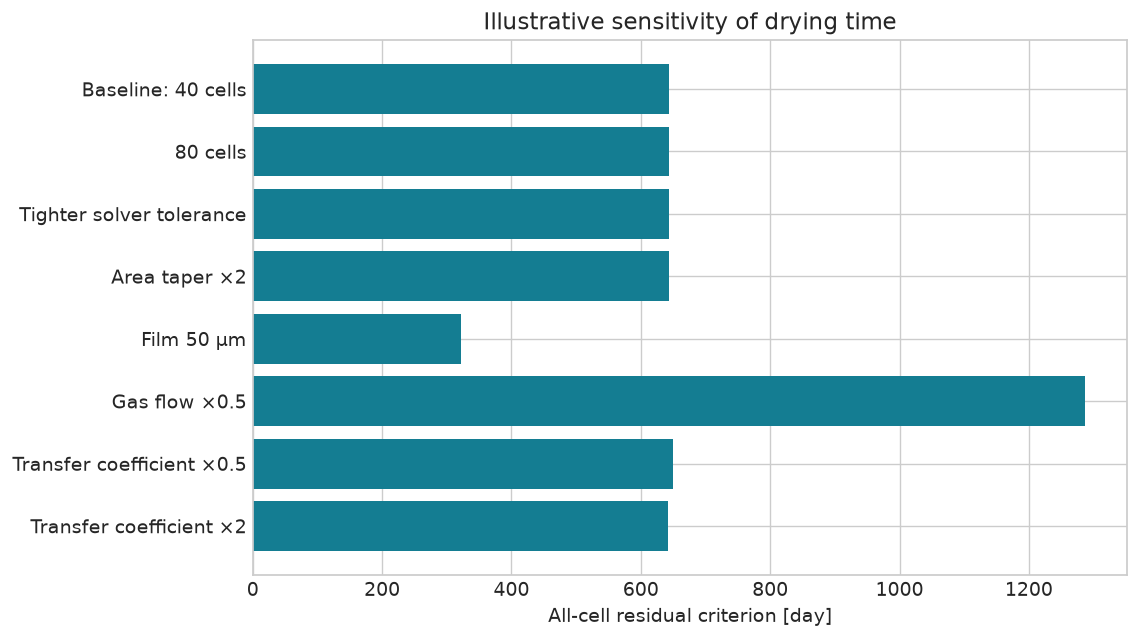

In [11]:
variants = [
    ("Baseline: 40 cells", case, baseline),
    ("80 cells", replace(case, cells=80), None),
    ("Tighter solver tolerance", replace(case, relative_tolerance=5e-7), None),
    ("Area taper ×2", replace(case, patch_fraction=2e-6), None),
    ("Film 50 µm", replace(case, film_thickness_um=50.0), None),
    ("Gas flow ×0.5", replace(case, gas_flow_Sm3_day=case.gas_flow_Sm3_day / 2), None),
    ("Transfer coefficient ×0.5", replace(case, mass_transfer_multiplier=0.5), None),
    ("Transfer coefficient ×2", replace(case, mass_transfer_multiplier=2.0), None),
]
sensitivity_rows = []
for label, settings, existing_result in variants:
    result = existing_result if existing_result is not None else simulate(settings)
    errors, smallest_mass = balance_check(result)
    sensitivity_rows.append({
        "Case": label,
        "Reached criterion": result["complete"],
        "Time [day]": result["last_day"],
        "Gas [million Sm³]": result["last_day"] * settings.gas_flow_Sm3_day / 1e6,
        "Max balance error [kg]": max(errors),
    })
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)
assert sensitivity["Reached criterion"].all(), "A sensitivity case did not reach the criterion."
refinement_change = abs(sensitivity.loc[1, "Time [day]"] / baseline["last_day"] - 1)
time_tolerance_change = abs(sensitivity.loc[2, "Time [day]"] / baseline["last_day"] - 1)
taper_change = abs(sensitivity.loc[3, "Time [day]"] / baseline["last_day"] - 1)
assert refinement_change < 0.05, "Refine the mesh further before interpreting dry-out time."
assert time_tolerance_change < 0.01
assert taper_change < 0.01
print(f"40 → 80 cells: {100 * refinement_change:.3f}% change in completion time")
print(f"Solver tolerance: {100 * time_tolerance_change:.3f}% change")
print(f"Area taper: {100 * taper_change:.3f}% change")

fig, axis = plt.subplots(figsize=(9, 5), layout="constrained")
axis.barh(sensitivity["Case"], sensitivity["Time [day]"], color="#147d92")
axis.invert_yaxis()
axis.set(
    xlabel="All-cell residual criterion [day]", title="Illustrative sensitivity of drying time",
)
plt.show()

## 7. Reusable results and engineering interpretation

The exported history, axial profiles and validation JSON retain the input/source provenance. They
can be passed to a larger startup study. `inlet_stream` and `process` are ordinary NeqSim objects;
the transient residual-film solver in this notebook is explicitly a Python extension, not a native
`PipelineEvaporationStudy.run()` calculation.

In [12]:
output_directory = Path("pigging_drying_results")
output_directory.mkdir(exist_ok=True)
history_table = pd.DataFrame({
    "time_day": sample_days,
    "water_film_kg": inventory_history[:, 0],
    "meg_film_kg": inventory_history[:, 1],
    "outlet_water_ppmv": outlet_ppmv[:, 0],
    "outlet_meg_ppmv": outlet_ppmv[:, 1],
    "outlet_water_dewpoint_C": outlet_dew_C,
})
profile_rows = []
for column, day in enumerate(snapshot_days):
    for cell_number, location in enumerate(locations_km):
        profile_rows.append({
            "time_day": float(day),
            "position_km": float(location),
            "film_thickness_um": float(snapshot_thickness_um[cell_number, column]),
            "water_mass_fraction": float(snapshot_water[cell_number, column]),
        })
profile_table = pd.DataFrame(profile_rows)
history_table.to_csv(output_directory / "history.csv", index=False)
profile_table.to_csv(output_directory / "profiles.csv", index=False)
sensitivity.to_csv(output_directory / "sensitivity.csv", index=False)
results = {
    "provenance": provenance,
    "inputs": case.__dict__,
    "completion_reached": baseline["complete"],
    "completion_days": baseline["last_day"],
    "retained_residue_kg": float(residual_kg),
    "dew_point_reference_bara": case.dew_point_pressure_bara,
    "peak_water_mass_kg": float(inventory_history[peak_water_index, 0]),
    "water_balance_residual_kg": float(balance_error[0]),
    "meg_balance_residual_kg": float(balance_error[1]),
    "spatial_refinement_change_fraction": float(refinement_change),
    "solver_tolerance_change_fraction": float(time_tolerance_change),
    "taper_change_fraction": float(taper_change),
    "capacity_lower_bound_days": float(capacity_lower_bound_days),
    "validation_level": "CPA equilibrium, analytical limits, conservation and numerical refinement",
    "field_drying_validation": False,
}
(output_directory / "results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
display(history_table.iloc[[0, peak_water_index, -1]])
print(f"The model predicts {baseline['last_day']:.1f} days to the specified residual criterion.")
print(
    f"That is {baseline['last_day'] / 365.25:.2f} years "
    "for the stated assumed film and gas flow."
)
print("A dry outlet gas reading can coexist with a substantial MEG film on the wall.")
print("Saved:", ", ".join(path.name for path in sorted(output_directory.iterdir())))

The model predicts 644.3 days to the specified residual criterion.
That is 1.76 years for the stated assumed film and gas flow.
A dry outlet gas reading can coexist with a substantial MEG film on the wall.
Saved: history.csv, profiles.csv, results.json, sensitivity.csv


,time_day,water_film_kg,meg_film_kg,outlet_water_ppmv,outlet_meg_ppmv,outlet_water_dewpoint_C
0,0,10.507,"1,040.2",35.536,0,-18
407,5.9567,82.597,"1,029.2",35.551,0.62002,-17.994
550,644.26,0.00019475,0.0024316,35.665,0.46722,-17.952


## Limitations and next steps

- **Film geometry governs the inventory.** Measure or bound the thickness, wall coverage and pooled
  liquid. This model has no puddles, corrosion roughness retention, drainage, re-entrainment or pig bypass.
- **Transfer closure is illustrative.** The gas-side correlation and high-pressure diffusivities need
  project validation. The film is internally mixed; liquid diffusion may matter at low temperature.
- **Temperature is held at 5 °C.** The surroundings implicitly supply evaporation heat and remove
  absorption/mixing heat. There is no energy balance or cooldown prediction. A thermal model is needed
  if the film/wall cannot remain near 5 °C.
- **Pressure and carrier composition are constant.** A small smooth-pipe pressure-drop screen supports
  this example only. Hydrocarbon condensation, hydrate/ice formation and changing dissolved-carrier
  inventory are excluded. Rich gas requires a revised phase/topology model if the CPA flash has oil.
- **The final microscopic tail is a threshold calculation.** Local wetting and diffusion are not
  resolved at molecular film thickness; reporting “exactly zero liquid” would overstate the model.
- **Early startup depends on the initial state.** To include pig transit, initialize film exposure times
  and the gas state behind a moving pig; do not interpret this reset-contact example as a pig model.
- **Native API opportunity:** current NeqSim `PipelineEvaporationStudy` marches flowing phase inventories
  along distance. A stationary, component-resolved wall-film inventory over startup time is a separate
  capability. Specific enhancement: [stationary-film drying #4281](https://github.com/equinor/neqsim/issues/4281).
  Related roadmap: [TwoFluidPipe #2907](https://github.com/equinor/neqsim/issues/2907).

Suggested exercises: replace diameter and film thickness with measured values; compare 25/50/100 µm;
change gas flow; rerun at a different temperature; tighten the residue criterion; compare a different
water dew point; add gas-to-wall heat transfer and liquid diffusion before field qualification.

## Sources and validation scope

1. [NeqSim source](https://github.com/equinor/neqsim), specifically `SystemSrkCPAstatoil`,
   `ThermodynamicOperations.TPflash` and
   [pipeline evaporation documentation](https://github.com/equinor/neqsim/blob/master/docs/fluidmechanics/PipelineLiquidEvaporation.md).
2. Folas et al. (2007), *High-pressure vapor–liquid equilibria of systems containing ethylene glycol,
   water and methane*, Fluid Phase Equilibria 251, 52–58,
   [DOI:10.1016/j.fluid.2006.11.001](https://doi.org/10.1016/j.fluid.2006.11.001).
   [NIST ThermoML record](https://trc.nist.gov/ThermoML/10.1016/j.fluid.2006.11.001.html).
   This is relevant CPA/VLE literature; the notebook does not claim to reproduce its full dataset.
3. Chilton and Colburn (1934), *Mass Transfer (Absorption) Coefficients Prediction from Data on
   Heat Transfer and Fluid Friction*, [DOI:10.1021/ie50299a012](https://doi.org/10.1021/ie50299a012).
   The analogy is applied to a smooth pipe with estimated diffusivities; this is not a calibration.
4. Petukhov (1970), *Heat Transfer and Friction in Turbulent Pipe Flow with Variable Physical
   Properties*, [DOI:10.1016/S0065-2717(08)70153-9](https://doi.org/10.1016/S0065-2717(08)70153-9).
5. [NIST Chemistry WebBook: ethylene glycol](https://webbook.nist.gov/cgi/cbook.cgi?ID=C107211&Mask=4),
   molecular identity and phase-change context. No out-of-range Antoine extrapolation is used.

Validation achieved: phase-equilibrium fugacity consistency, component conservation including gas
holdup, an analytical advection limit, an equilibrium-capacity lower bound, nearby input cases, and
mesh/solver/taper sensitivity. **Absolute field drying time has not been validated experimentally.**